FRAUD DETECTION PROJECT

[STEP 1] Loading Dataset...
Dataset loaded successfully!
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533

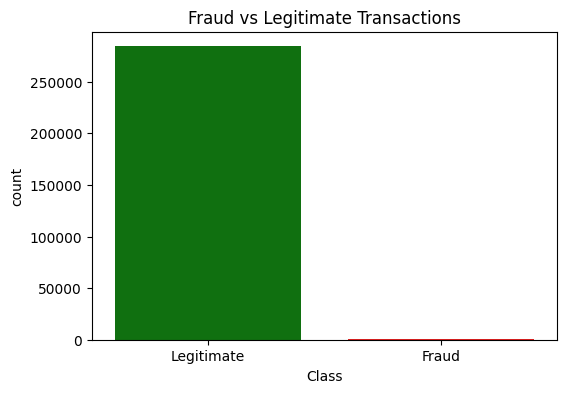


[STEP 4] Feature Engineering...
Features prepared & scaled

[STEP 5] Handling Class Imbalance using SMOTE...
After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64

[STEP 6] Train-Test Split...
Training Samples: 454904
Testing Samples : 113726

[STEP 7] Training Machine Learning Models...

Training Logistic Regression...
Precision: 0.9903
Recall   : 0.9714
F1-Score : 0.9808
ROC-AUC  : 0.9975

Training Decision Tree...
Precision: 0.9908
Recall   : 0.9928
F1-Score : 0.9918
ROC-AUC  : 0.9981

Training Random Forest...
Precision: 0.9982
Recall   : 0.9841
F1-Score : 0.9911
ROC-AUC  : 0.9995

Best Model Selected: Decision Tree

[STEP 9] Model Evaluation...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99     56863
       Fraud       0.99      0.99      0.99     56863

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0

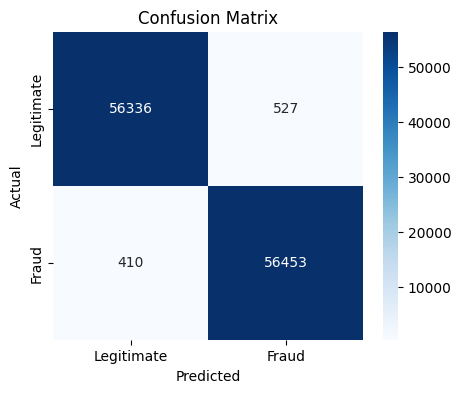


[STEP 10] Real-Time Fraud Detection Function...
Real-time fraud detection function created

PROJECT SUMMARY

• Dataset: Credit Card Transactions
• Severe class imbalance handled using SMOTE
• Models Used:
  - Logistic Regression
  - Decision Tree
  - Random Forest
• Best Model: Decision Tree
• Focus Metric: F1-Score
• System supports real-time fraud detection

✓ FRAUD DETECTION PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# Fraud Detection - Oasis Infobyte Internship
# Author: Muhammad Talhah Rizwan Sayyed
# Project: Level 2 - Fraud Detection using Machine Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

print("="*70)
print("FRAUD DETECTION PROJECT")
print("="*70)

# ===============================================================
# STEP 1: DATA LOADING
# ===============================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

# ===============================================================
# STEP 2: DATA EXPLORATION
# ===============================================================
print("\n[STEP 2] Data Exploration...")

print("\nFraud Distribution:")
print(df['Class'].value_counts())

fraud_percentage = df['Class'].value_counts(normalize=True)[1] * 100
print(f"\nFraud Percentage: {fraud_percentage:.2f}%")

# ===============================================================
# STEP 3: DATA VISUALIZATION
# ===============================================================
print("\n[STEP 3] Data Visualization...")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['green', 'red'])
plt.title("Fraud vs Legitimate Transactions")
plt.xticks([0,1], ['Legitimate', 'Fraud'])
plt.show()

# ===============================================================
# STEP 4: FEATURE ENGINEERING
# ===============================================================
print("\n[STEP 4] Feature Engineering...")

X = df.drop(columns=['Class'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

print("Features prepared & scaled")

# ===============================================================
# STEP 5: HANDLE CLASS IMBALANCE (SMOTE)
# ===============================================================
print("\n[STEP 5] Handling Class Imbalance using SMOTE...")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# ===============================================================
# STEP 6: TRAIN-TEST SPLIT
# ===============================================================
print("\n[STEP 6] Train-Test Split...")

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"Training Samples: {len(y_train)}")
print(f"Testing Samples : {len(y_test)}")

# ===============================================================
# STEP 7: MODEL TRAINING
# ===============================================================
print("\n[STEP 7] Training Machine Learning Models...")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "model": model,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "predictions": y_pred
    }

    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

# ===============================================================
# STEP 8: BEST MODEL SELECTION
# ===============================================================
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']

print("\nBest Model Selected:", best_model_name)

# ===============================================================
# STEP 9: MODEL EVALUATION
# ===============================================================
print("\n[STEP 9] Model Evaluation...")

y_pred_best = results[best_model_name]['predictions']

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Legitimate", "Fraud"]))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Legitimate", "Fraud"],
            yticklabels=["Legitimate", "Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===============================================================
# STEP 10: REAL-TIME FRAUD DETECTION FUNCTION
# ===============================================================
print("\n[STEP 10] Real-Time Fraud Detection Function...")

def detect_fraud(transaction_data):
    input_df = pd.DataFrame([transaction_data])
    input_df['Amount'] = scaler.transform(input_df[['Amount']])

    prediction = best_model.predict(input_df)[0]
    probability = best_model.predict_proba(input_df)[0][1]

    return {
        "Prediction": "FRAUD" if prediction == 1 else "LEGITIMATE",
        "Fraud_Probability": round(probability, 4)
    }

print("Real-time fraud detection function created")

# ===============================================================
# STEP 11: SUMMARY
# ===============================================================
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"""
• Dataset: Credit Card Transactions
• Severe class imbalance handled using SMOTE
• Models Used:
  - Logistic Regression
  - Decision Tree
  - Random Forest
• Best Model: {best_model_name}
• Focus Metric: F1-Score
• System supports real-time fraud detection
""")

print("✓ FRAUD DETECTION PROJECT COMPLETED SUCCESSFULLY!")
